In [30]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
SEX_CONDITION_PALETTE = {
    ('M', 'WT'): '#004a99',  # Control male
    ('M', 'KO'): '#90bff9',  # SkM-KO male
    ('F', 'WT'): '#f71480',  # Control female
    ('F', 'KO'): '#fa98c7',  # SkM-KO female
}

# Sex-only collapse (used when a plot isn't split by condition — picks WT shade).
SEX_PALETTE = {
    'F': SEX_CONDITION_PALETTE[('F', 'WT')],
    'M': SEX_CONDITION_PALETTE[('M', 'WT')],
}

# Make sure SVG text stays editable in Illustrator (text elements, not paths).
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": "none",
})
figure_params = {
    "dpi": 300,
    "bbox_inches": "tight",
    "format": "svg",
    "transparent": True,
}

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

## Females (Z12 and Z15) 

In [32]:
Z12_file = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/slide_outs/optimize_slide/female_0.1_spec/0.01_0.1_out/feature_list_Z12.txt'
Z15_file = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/metacell/slide_outs/optimize_slide/female_0.1_spec/0.01_0.1_out/feature_list_Z15.txt'

In [33]:
# read as pandas df
Z12_df = pd.read_csv(Z12_file, sep='\t', header=0)
Z15_df = pd.read_csv(Z15_file, sep='\t', header=0)
display(Z12_df.head())

,names,A_loading,AUCs,corrs,color
0,Pdk4,1.000000,0.755747,0.442784,Red
1,Ucp3,1.000000,0.681999,0.315101,Red
2,Pak7,0.082310,0.639643,0.292867,Red
3,Nrp1,0.073349,0.441663,-0.101008,Blue
4,Commd10,0.072824,0.457782,-0.073093,Blue


### Z12_Females

In [34]:
"""
Reusable Nature-style dot plot for a SLIDE latent factor.

Inputs
------
df             : DataFrame with at least the columns ['names', <metric>].
pathway_map    : dict {gene_name: pathway_label}
palette        : dict {pathway_label: hex_color}
latent_factor  : str — used in the output filename (e.g. "Z12").
figures_dir    : str — directory to write the SVG into.
sex            : optional str (e.g. "female", "male"). When given, embedded in
                 the output filename so sex-split LF files don't overwrite each other.
metric         : column name in df to plot on the x-axis (default "AUCs").
                 Also embedded in the output filename and axis label.
metric_label   : axis-label text. Defaults to `metric`.
default_pathway: label assigned to genes missing from pathway_map.
figsize        : matplotlib figsize tuple.
"""

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Global rcParams — Nature-style + Illustrator-editable text
mpl.rcParams.update({
    "svg.fonttype":      "none",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth":    0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
})


def plot_lf_dotplot(
    df,
    pathway_map,
    palette,
    latent_factor,
    figures_dir,
    sex=None,
    metric="AUCs",
    metric_label=None,
    default_pathway="Non-coding/uncharacterized",
    figsize=(7.5, 8.5),
    legend_title="Classifications",
):
    if metric not in df.columns:
        raise KeyError(
            f"metric column '{metric}' not in df.columns ({list(df.columns)})"
        )
    metric_label = metric_label if metric_label is not None else metric

    df = df.copy()
    df["pathway"] = df["names"].map(pathway_map).fillna(default_pathway)

    fig, ax = plt.subplots(figsize=figsize)

    vmax = df[metric].max()
    vmin = df[metric].min()
    x_pad = (vmax - min(vmin, 0)) * 0.04
    # lollipop baseline: 0 if values are non-negative, otherwise the min value.
    line_start = 0 if vmin >= 0 else vmin

    y_pos = list(range(len(df)))
    for i, (_, row) in enumerate(df.iterrows()):
        c = palette[row["pathway"]]
        ax.plot([line_start, row[metric]], [i, i],
                linestyle="--", color="0.65", linewidth=0.9,
                dash_capstyle="round", zorder=1)
        ax.scatter(row[metric], i,
                   color=c, s=85, edgecolor="white",
                   linewidth=0.7, zorder=2, clip_on=False)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["names"], fontstyle="italic")
    ax.invert_yaxis()

    ax.set_xlabel(metric_label, labelpad=8)
    ax.set_ylabel("Gene", labelpad=8)

    # x-range that respects negatives (e.g. A_loading can be signed)
    lo = min(vmin, 0) - x_pad * 0.5
    hi = vmax + x_pad * 3
    ax.set_xlim(lo, hi)
    ax.set_ylim(len(df) - 0.5 + 0.6, -0.5 - 0.6)

    ax.xaxis.grid(True, linestyle=":", color="0.85", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", pad=4)

    # Only show legend entries for pathways present in this LF (preserving palette order).
    present = [p for p in palette.keys() if p in set(df["pathway"])]
    handles = [Line2D([0], [0], marker="o", linestyle="",
                      color=palette[p], label=p, markersize=8)
               for p in present]
    leg = ax.legend(handles=handles, title=legend_title,
                    frameon=False,
                    loc="center left",
                    bbox_to_anchor=(1.02, 0.5),
                    labelspacing=1.1, borderpad=0.0, handletextpad=0.6)
    leg.get_title().set_fontweight("bold")
    leg._legend_box.align = "left"

    plt.subplots_adjust(left=0.14, right=0.74, top=0.97, bottom=0.08)

    # Filename: {latent_factor}_{sex}_{metric}_dotplot.svg
    # e.g. Z12_female_AUCs_dotplot.svg ; sex omitted if not provided.
    safe_metric = str(metric).replace("/", "_").replace(" ", "_")
    parts = [latent_factor]
    if sex is not None:
        parts.append(str(sex))
    parts += [safe_metric, "dotplot"]
    out_path = f"{figures_dir}/{'_'.join(parts)}.svg"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    return out_path

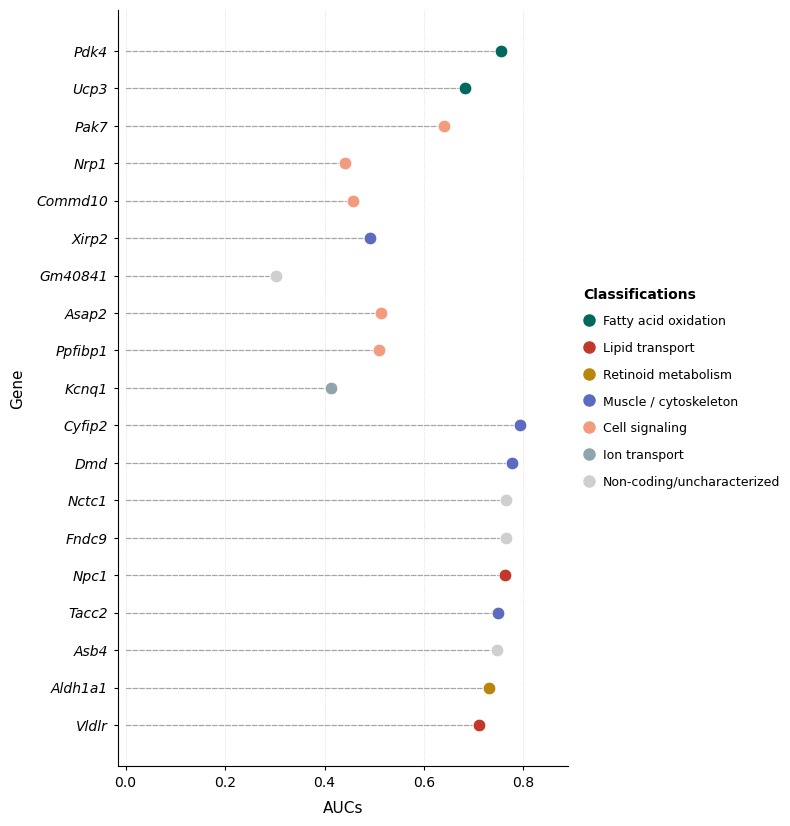

'/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/Z12_female_AUCs_dotplot.svg'

In [36]:
# ---- Z12 (Females) ---------------------------------------------------
pathway_map_Z12 = {
    "Pdk4":    "Fatty acid oxidation",
    "Ucp3":    "Fatty acid oxidation",
    "Npc1":    "Lipid transport",
    "Vldlr":   "Lipid transport",
    "Aldh1a1": "Retinoid metabolism",
    "Xirp2":   "Muscle / cytoskeleton",
    "Dmd":     "Muscle / cytoskeleton",
    "Cyfip2":  "Muscle / cytoskeleton",
    "Tacc2":   "Muscle / cytoskeleton",
    "Pak7":    "Cell signaling",
    "Nrp1":    "Cell signaling",
    "Commd10": "Cell signaling",
    "Asap2":   "Cell signaling",
    "Ppfibp1": "Cell signaling",
    "Kcnq1":   "Ion transport",
    "Gm40841": "Non-coding/uncharacterized",
    "Nctc1":   "Non-coding/uncharacterized",
    "Fndc9":   "Non-coding/uncharacterized",
    "Asb4":    "Non-coding/uncharacterized",
}

palette_Z12 = {
    "Fatty acid oxidation":        "#00695C",
    "Lipid transport":             "#C0392B",
    "Retinoid metabolism":         "#B8860B",
    "Muscle / cytoskeleton":       "#5C6BC0",
    "Cell signaling":              "#F39B7F",
    "Ion transport":               "#90A4AE",
    "Non-coding/uncharacterized":  "#CFCFCF",
}

# A_loading version → writes Z12_female_A_loading_dotplot.svg
plot_lf_dotplot(
    df=Z12_df,
    pathway_map=pathway_map_Z12,
    palette=palette_Z12,
    latent_factor="Z12",
    figures_dir=figures_dir,
    sex="female",
    metric="AUCs",
)

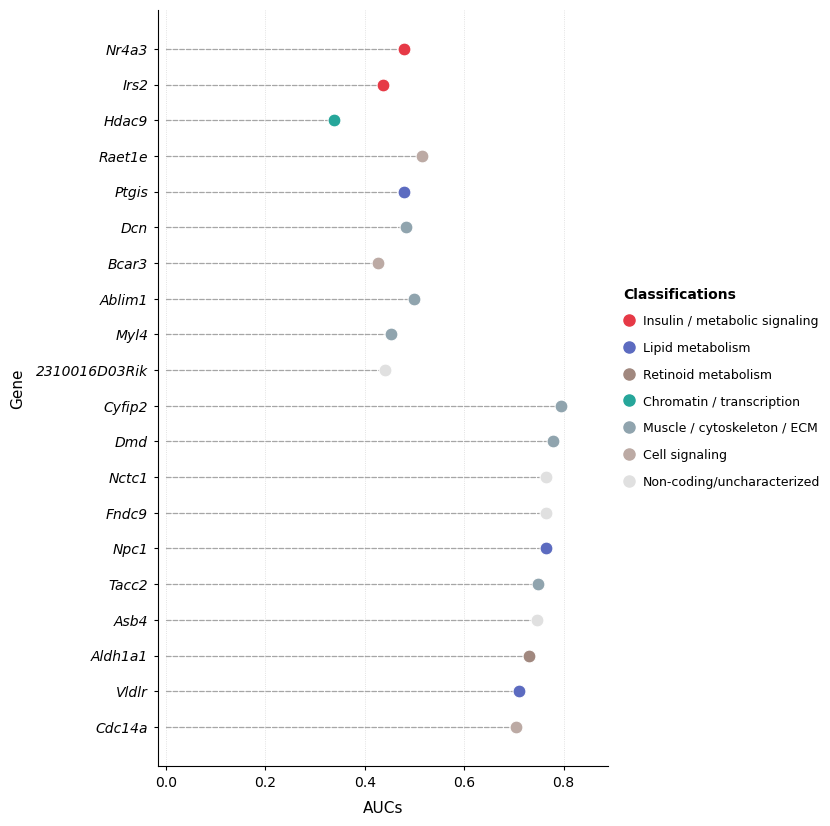

'/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/Z15_female_AUCs_dotplot.svg'

In [37]:
# ---- Z15 (Nr4a3 / Irs2 LF) -------------------------------------
pathway_map_Z15 = {
    # insulin / metabolic signaling node (interacts with Pdk4 in Z12)
    "Nr4a3":         "Insulin / metabolic signaling",
    "Irs2":          "Insulin / metabolic signaling",
    # Lipid metabolism (incl. eicosanoid biosynthesis from arachidonate)
    "Npc1":          "Lipid metabolism",
    "Vldlr":         "Lipid metabolism",
    "Ptgis":         "Lipid metabolism",
    # Retinoid metabolism
    "Aldh1a1":       "Retinoid metabolism",
    # Chromatin / transcription
    "Hdac9":         "Chromatin / transcription",
    # Muscle / cytoskeleton / ECM
    "Ablim1":        "Muscle / cytoskeleton / ECM",
    "Myl4":          "Muscle / cytoskeleton / ECM",
    "Cyfip2":        "Muscle / cytoskeleton / ECM",
    "Dmd":           "Muscle / cytoskeleton / ECM",
    "Tacc2":         "Muscle / cytoskeleton / ECM",
    "Dcn":           "Muscle / cytoskeleton / ECM",
    # Cell signaling (kinase/phosphatase/adhesion/immune adapters)
    "Bcar3":         "Cell signaling",
    "Cdc14a":        "Cell signaling",
    "Raet1e":        "Cell signaling",
    # Non-coding / uncharacterized
    "2310016D03Rik": "Non-coding/uncharacterized",
    "Nctc1":         "Non-coding/uncharacterized",
    "Fndc9":         "Non-coding/uncharacterized",
    "Asb4":          "Non-coding/uncharacterized",
}

palette_Z15 = {
    "Insulin / metabolic signaling": "#E63946",   # vivid crimson — HERO
    "Lipid metabolism":              "#5C6BC0",   # muted indigo
    "Retinoid metabolism":           "#A1887F",   # warm brown
    "Chromatin / transcription":     "#26A69A",   # muted teal
    "Muscle / cytoskeleton / ECM":   "#90A4AE",   # cool slate grey
    "Cell signaling":                "#BCAAA4",   # warm grey
    "Non-coding/uncharacterized":    "#E0E0E0",   # near-white
}

plot_lf_dotplot(
    df=Z15_df,
    pathway_map=pathway_map_Z15,
    palette=palette_Z15,
    latent_factor="Z15",
    figures_dir=figures_dir,
    sex="female"   # change to "male" if Z15 is the male LF
)